# Spam Email Analytics & Classification

**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn, NLP

## Objective
Analyze a labeled email/SMS message dataset, identify patterns associated with spam messages, and build machine-learning classifiers for spam detection.

## Workflow
1. Load and inspect the data
2. Clean and validate the dataset
3. Perform exploratory data analysis (EDA)
4. Engineer simple text-based features
5. Convert text to TF-IDF features
6. Train and compare classification models
7. Evaluate accuracy, precision, recall, F1-score and confusion matrices
8. Generate a prediction dataset that can be used for a Power BI dashboard

> This notebook is a fresh implementation built around the supplied `mail_data.csv` dataset. The analysis, feature engineering, model comparison and visualizations are implemented here rather than copying the original notebook structure.


In [1]:
# Install once if needed:
# %pip install pandas numpy matplotlib seaborn scikit-learn wordcloud

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
DATA_PATH = "../data/mail_data.csv"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes)


Dataset shape: (5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Columns: ['Category', 'Message']

Data types:


Category    object
Message     object
dtype: object

## 2. Data quality checks

In [3]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print("Duplicate rows:", df.duplicated().sum())
print("\nClass distribution:")
display(df["Category"].value_counts().to_frame("Count"))

print("\nClass percentage:")
display((df["Category"].value_counts(normalize=True) * 100).round(2).to_frame("Percentage"))


Missing values:


,Missing
Category,0
Message,0


Duplicate rows: 415

Class distribution:


,Count
Category,
ham,4825
spam,747



Class percentage:


,Percentage
Category,
ham,86.59
spam,13.41


### Cleaning decisions

- Remove exact duplicate records so the same message does not appear multiple times in the analysis.
- Remove rows with missing message/category values if any are present.
- Keep the original message text for NLP and create separate numeric features for EDA.


In [4]:
df = df.dropna(subset=["Category", "Message"]).copy()
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed_duplicates = before - len(df)

print(f"Rows after cleaning: {len(df):,}")
print(f"Duplicate rows removed: {removed_duplicates:,}")
print("\nFinal class distribution:")
display(df["Category"].value_counts().to_frame("Count"))


Rows after cleaning: 5,157
Duplicate rows removed: 415

Final class distribution:


,Count
Category,
ham,4516
spam,641


## 3. Feature engineering for exploratory analysis

In [5]:
df["Message_Length"] = df["Message"].str.len()
df["Word_Count"] = df["Message"].str.split().str.len()
df["Character_Count_No_Spaces"] = df["Message"].str.replace(r"\s+", "", regex=True).str.len()
df["Exclamation_Count"] = df["Message"].str.count("!")
df["Digit_Count"] = df["Message"].str.count(r"\d")

display(df[["Category", "Message_Length", "Word_Count",
            "Character_Count_No_Spaces", "Exclamation_Count", "Digit_Count"]].head())


,Category,Message_Length,Word_Count,Character_Count_No_Spaces,Exclamation_Count,Digit_Count
0,ham,111,20,92,0,0
1,ham,29,6,24,0,0
2,spam,155,28,128,0,25
3,ham,49,11,39,0,0
4,ham,61,13,49,0,0


## 4. Exploratory Data Analysis

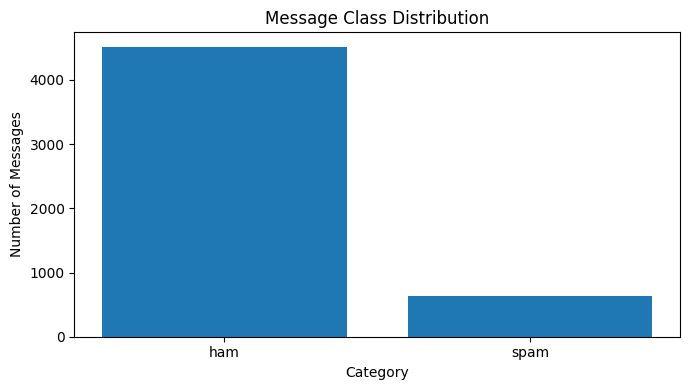

In [6]:
# Spam vs ham distribution
class_counts = df["Category"].value_counts().reindex(["ham", "spam"])

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Message Class Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


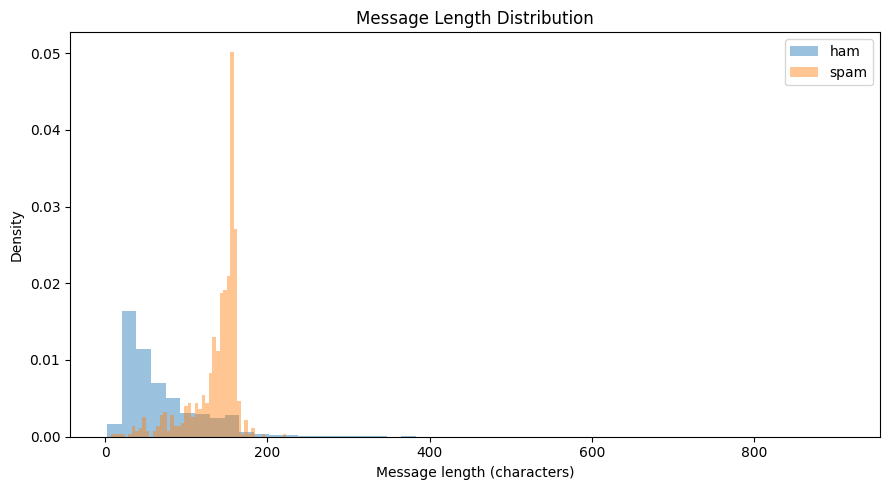

,Message_Length,Word_Count,Digit_Count,Exclamation_Count
Category,,,,
ham,70.87,14.24,0.30,0.18
spam,137.12,23.66,15.33,0.69


In [7]:
# Compare message length
plt.figure(figsize=(9, 5))
for label in ["ham", "spam"]:
    values = df.loc[df["Category"] == label, "Message_Length"]
    plt.hist(values, bins=50, density=True, alpha=0.45, label=label)
plt.title("Message Length Distribution")
plt.xlabel("Message length (characters)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/message_length_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    df.groupby("Category")[["Message_Length", "Word_Count", "Digit_Count", "Exclamation_Count"]]
      .mean().round(2)
)


### Frequent words

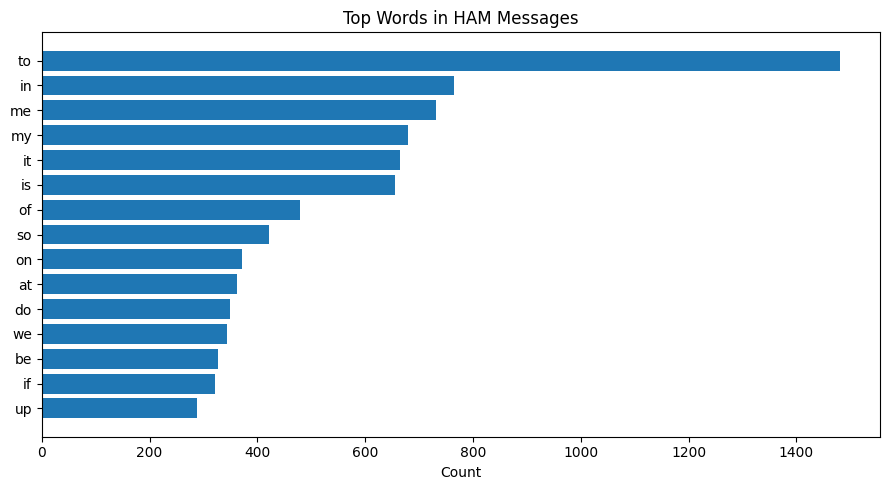

Top words for ham:


,Word,Count
0,to,1481
1,in,764
2,me,732
3,my,680
4,it,664
5,is,656
6,of,479
7,so,421
8,on,372
9,at,362


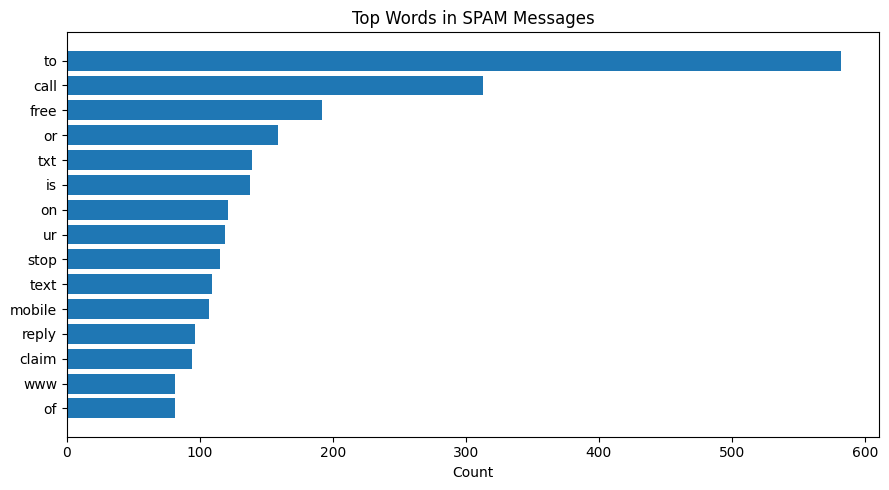

Top words for spam:


,Word,Count
0,to,582
1,call,313
2,free,192
3,or,159
4,txt,139
5,is,138
6,on,121
7,ur,119
8,stop,115
9,text,109


In [8]:
def clean_words(text):
    text = text.lower()
    return re.findall(r"[a-zA-Z]{2,}", text)

stop_words = {
    "the","and","for","you","are","with","this","that","have","from","your",
    "will","but","not","was","can","all","our","has","had","what","when",
    "where","who","how","why","its","out","get","got","just","they","them",
    "been","there","here","then","than","too","very","into","about","would",
    "could","should","now","like","please","also","only","more","some"
}

for label in ["ham", "spam"]:
    words = []
    for message in df.loc[df["Category"] == label, "Message"]:
        words.extend(w for w in clean_words(message) if w not in stop_words)
    counts = Counter(words).most_common(15)
    top_words = pd.DataFrame(counts, columns=["Word", "Count"])

    plt.figure(figsize=(9, 5))
    plt.barh(top_words["Word"][::-1], top_words["Count"][::-1])
    plt.title(f"Top Words in {label.upper()} Messages")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/top_words_{label}.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Top words for {label}:")
    display(top_words)


## 5. Prepare data for machine learning

In [9]:
# Encode target: ham = 0, spam = 1
df["Target"] = df["Category"].map({"ham": 0, "spam": 1})

X = df["Message"]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Training spam rate:", round(y_train.mean() * 100, 2), "%")
print("Testing spam rate:", round(y_test.mean() * 100, 2), "%")


Training records: 4125
Testing records: 1032
Training spam rate: 12.44 %
Testing spam rate: 12.4 %


## 6. TF-IDF text representation

TF-IDF converts text into numerical features by giving higher importance to terms that are informative within the dataset while reducing the influence of very common terms.

The vectorizer is placed **inside each scikit-learn pipeline**, so it is fitted only on the training data and does not leak information from the test set.


## 7. Train and compare models

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                sublinear_tf=True
            )
        ),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fitted_models[name] = pipeline
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("F1 Score", ascending=False)
      .reset_index(drop=True)
)

display(results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}"
}))


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.981,0.958,0.883,0.919
1,Logistic Regression,0.958,0.989,0.672,0.800
2,Multinomial Naive Bayes,0.955,1.000,0.641,0.781


## 8. Visualize model performance

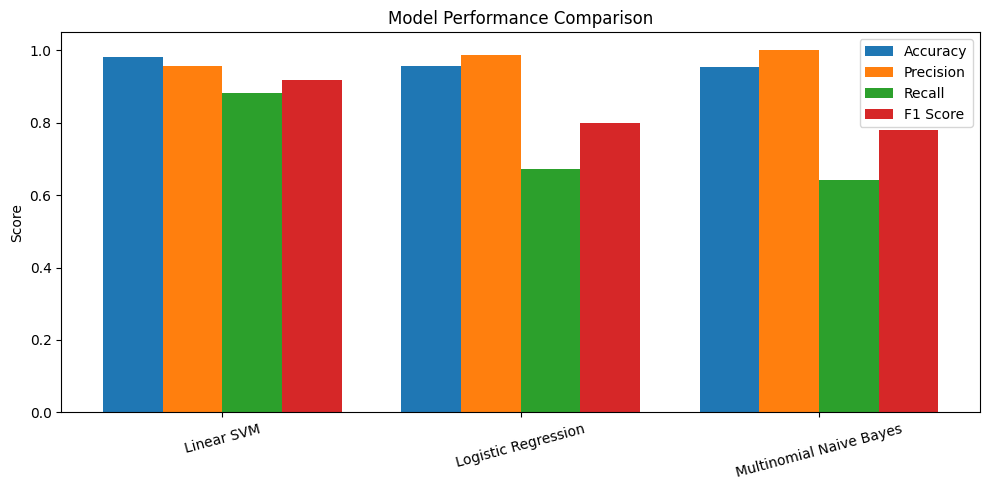

In [11]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(results_df))
width = 0.2

plt.figure(figsize=(10, 5))
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1.5) * width, results_df[metric], width, label=metric)

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Confusion matrix for the selected model

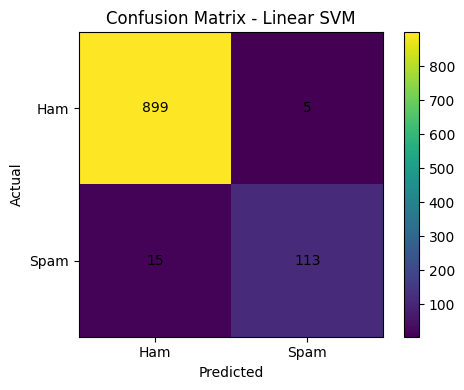

Selected model based on F1 score: Linear SVM

Classification report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       904
        Spam       0.96      0.88      0.92       128

    accuracy                           0.98      1032
   macro avg       0.97      0.94      0.95      1032
weighted avg       0.98      0.98      0.98      1032



In [12]:
best_model_name = results_df.loc[0, "Model"]
best_pipeline = fitted_models[best_model_name]
best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()
plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Selected model based on F1 score: {best_model_name}")
print("\nClassification report:")
print(classification_report(
    y_test, best_pred,
    target_names=["Ham", "Spam"]
))


## 10. Test the classifier on new messages

In [13]:
sample_messages = [
    "Congratulations! You have won a free prize. Call now to claim your reward.",
    "Hi, are we still meeting for lunch at 1 pm today?",
    "URGENT! You have been selected for a cash reward. Reply now."
]

sample_predictions = best_pipeline.predict(sample_messages)

sample_output = pd.DataFrame({
    "Message": sample_messages,
    "Prediction": np.where(sample_predictions == 1, "Spam", "Ham")
})

display(sample_output)


,Message,Prediction
0,Congratulations! You have won a free prize. Ca...,Spam
1,"Hi, are we still meeting for lunch at 1 pm today?",Ham
2,URGENT! You have been selected for a cash rewa...,Spam


## 11. Create an analysis file for Power BI

The following output combines the cleaned records with simple text features and predictions. It can be imported into Power BI for an interactive portfolio dashboard.


In [14]:
# Predict the complete cleaned dataset with the selected model
df["Prediction"] = best_pipeline.predict(df["Message"])
df["Prediction_Label"] = df["Prediction"].map({0: "Ham", 1: "Spam"})

dashboard_df = df[
    [
        "Category", "Message", "Message_Length", "Word_Count",
        "Character_Count_No_Spaces", "Exclamation_Count",
        "Digit_Count", "Prediction_Label"
    ]
].copy()

dashboard_path = f"{OUTPUT_DIR}/spam_email_powerbi_data.csv"
dashboard_df.to_csv(dashboard_path, index=False)

print(f"Power BI-ready file saved to: {dashboard_path}")
display(dashboard_df.head())


Power BI-ready file saved to: ../outputs/spam_email_powerbi_data.csv


,Category,Message,Message_Length,Word_Count,Character_Count_No_Spaces,Exclamation_Count,Digit_Count,Prediction_Label
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,92,0,0,Ham
1,ham,Ok lar... Joking wif u oni...,29,6,24,0,0,Ham
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,128,0,25,Spam
3,ham,U dun say so early hor... U c already then say...,49,11,39,0,0,Ham
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,49,0,0,Ham


## 12. Key takeaways

- The dataset is imbalanced, with legitimate messages substantially more common than spam.
- Message-level features such as length and word count can be compared across the two classes.
- TF-IDF provides a practical numerical representation for text classification.
- Model performance should be evaluated using more than accuracy; precision, recall and F1-score are especially useful when the positive class is less frequent.
- The exported prediction file can be used to build a Power BI dashboard showing class distribution, message characteristics and prediction outcomes.

### Portfolio extension
A useful next step is to build a Power BI report from `outputs/spam_email_powerbi_data.csv` with KPI cards, class distribution, message-length analysis, and prediction breakdowns.
